# 10. Clustering y Reducción de Dimensionalidad 🔍

En este notebook aprenderás técnicas de clustering (agrupamiento) y reducción de dimensionalidad, con ejemplos prácticos usando scikit-learn.

✨ **Highlights:**
- K-Means con método del codo + silhouette score para elegir K óptimo
- DBSCAN: clustering de forma libre con detección de outliers
- PCA con varianza explicada y análisis de componentes
- t-SNE con comparación de perplexity y tiempos de cómputo

## Objetivo
- Comprender la teoría y aplicaciones de clustering y reducción de dimensionalidad.
- Implementar K-Means, DBSCAN, PCA y t-SNE.
- Usar el método del codo para elegir K.
- Evaluar clustering con métricas cuantitativas.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01](./01_intro_machine_learning.ipynb) y [02](./02_preprocesamiento_visualizacion.ipynb).

- Conceptos de escalado, PCA, y evaluación de modelos.

## 1. Introducción teórica

| Técnica | Tipo | Ventaja | Desventaja |
|---------|------|---------|------------|
| **K-Means** | Clustering | Rápido, escalable | Requiere K, clusters esféricos |
| **DBSCAN** | Clustering | Forma libre, detecta outliers | Sensible a eps y min_samples |
| **PCA** | Reducción | Lineal, rápido, preserva varianza | Solo relaciones lineales |
| **t-SNE** | Reducción | Preserva estructura local | Solo para visualización, lento |

## 2. Importación de librerías

In [1]:
import random
import numpy as np
import time

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
%matplotlib inline

print('Librerías cargadas ✅')

Librerías cargadas ✅


## 3. Carga y exploración del dataset

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


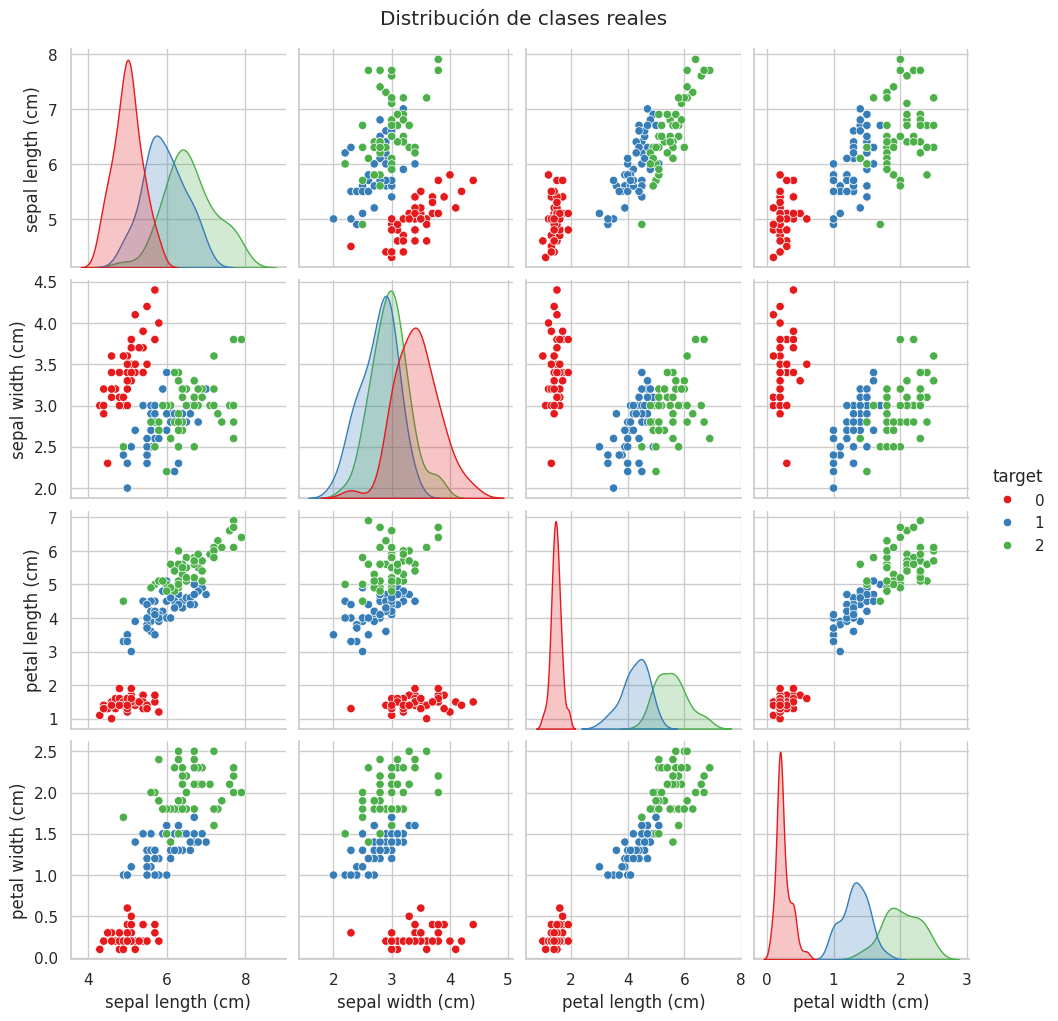

In [3]:
sns.pairplot(df, hue='target', palette='Set1')
plt.suptitle('Distribución de clases reales', y=1.02)
plt.show()

## 4. Preprocesamiento

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])
print('Media:', X_scaled.mean(axis=0).round(2))
print('Desviación estándar:', X_scaled.std(axis=0).round(2))

Media: [-0. -0. -0. -0.]
Desviación estándar: [1. 1. 1. 1.]


## 5. Método del Codo para elegir K

El método del codo grafica la inercia (suma de distancias al centroide) vs K, buscando el punto donde la reducción de inercia se desacelera.

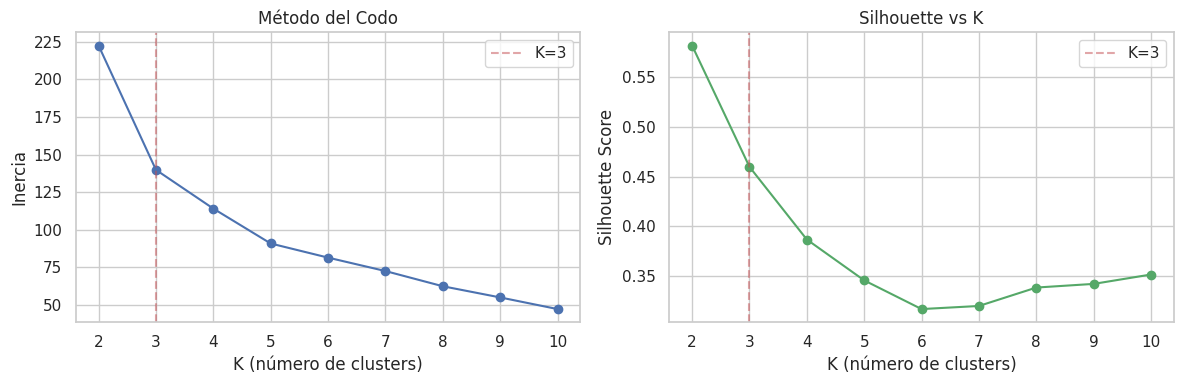

In [5]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('K (número de clusters)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].axvline(x=3, color='r', linestyle='--', alpha=0.5, label='K=3')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_xlabel('K (número de clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette vs K')
axes[1].axvline(x=3, color='r', linestyle='--', alpha=0.5, label='K=3')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Clustering: K-Means

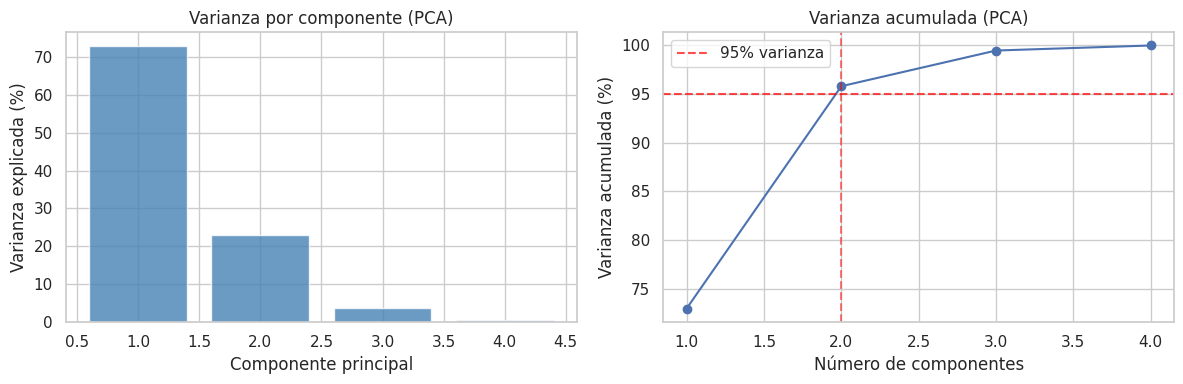

💡 Con 2 componentes se explica el 95% de la varianza (de 4 features originales)


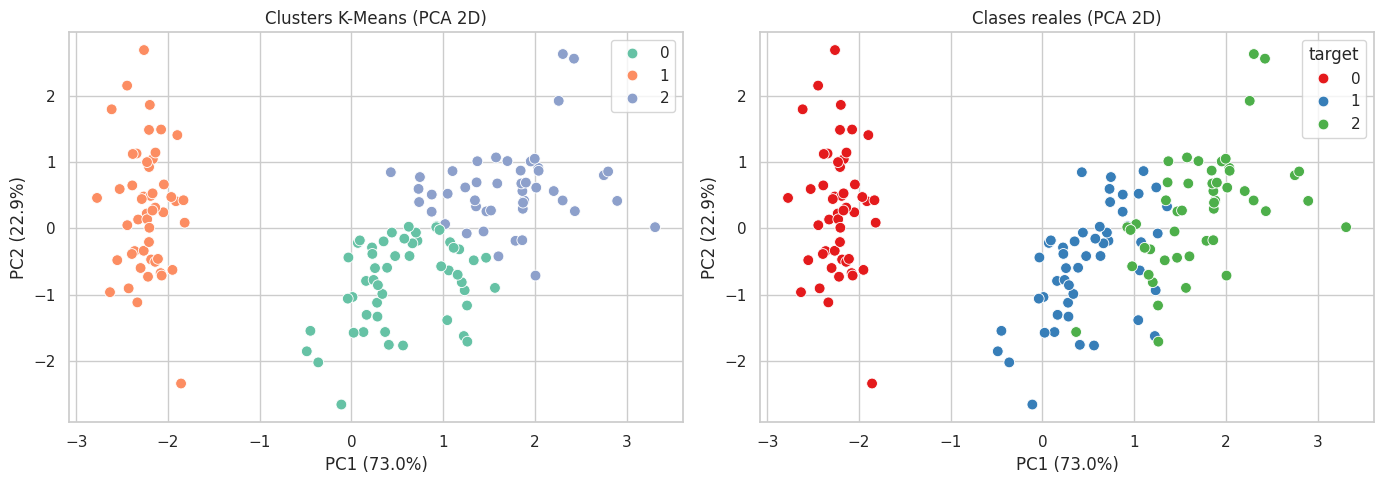

Silhouette Score K-Means: 0.460
Adjusted Rand Index:      0.620

💡 Silhouette Score: rango [-1, 1]; >0.5 es bueno. ARI: 1.0 es perfecto.


In [6]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

# Varianza explicada acumulada
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente (PCA)')

axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, 'bo-')
axes[1].axhline(95, color='red', linestyle='--', alpha=0.7, label='95% varianza')
n_95 = np.argmax(cum_var >= 0.95) + 1
axes[1].axvline(n_95, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada (PCA)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'💡 Con {n_95} componentes se explica el 95% de la varianza (de {X_scaled.shape[1]} features originales)')

# PCA 2D para visualización
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2', s=60, ax=axes[0])
axes[0].set_title('Clusters K-Means (PCA 2D)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['target'], palette='Set1', s=60, ax=axes[1])
axes[1].set_title('Clases reales (PCA 2D)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

print(f'Silhouette Score K-Means: {silhouette_score(X_scaled, clusters):.3f}')
print(f'Adjusted Rand Index:      {adjusted_rand_score(df["target"], clusters):.3f}')
print('\n💡 Silhouette Score: rango [-1, 1]; >0.5 es bueno. ARI: 1.0 es perfecto.')

## 7. Clustering: DBSCAN

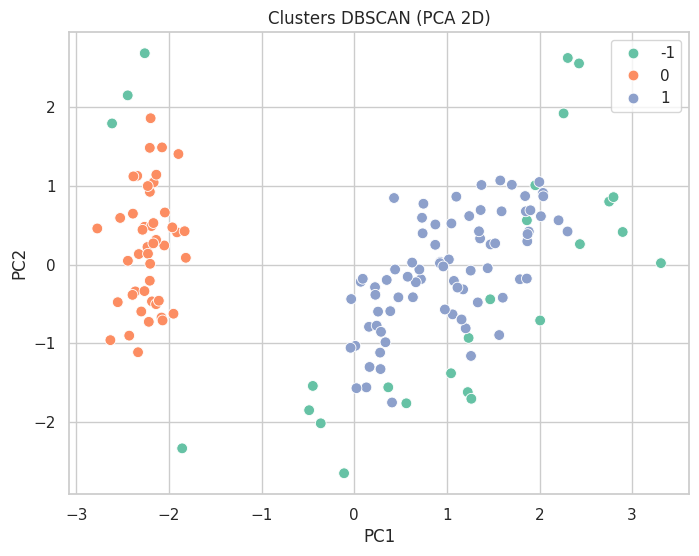

Clusters encontrados: 2  |  Outliers (ruido): 26
Silhouette Score DBSCAN: 0.403
Adjusted Rand Index:     0.471

📊 Sensibilidad de DBSCAN al parámetro eps (min_samples=5):
     eps |  Clusters |  Outliers |     Sil.
------------------------------------------
     0.3 |         3 |       120 |   -0.194
     0.5 |         2 |        34 |    0.357
     0.6 |         2 |        26 |    0.403
     0.8 |         2 |         4 |    0.522
     1.0 |         2 |         3 |    0.538
     1.5 |         2 |         0 |    0.582

💡 Ajusta eps usando k-NN: grafica distancias al k-ésimo vecino y busca el "codo".


In [7]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=db_clusters, palette='Set2', s=60)
plt.title('Clusters DBSCAN (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise = list(db_clusters).count(-1)
print(f'Clusters encontrados: {n_clusters}  |  Outliers (ruido): {n_noise}')
if len(set(db_clusters)) > 1:
    print(f'Silhouette Score DBSCAN: {silhouette_score(X_scaled, db_clusters):.3f}')
    print(f'Adjusted Rand Index:     {adjusted_rand_score(df["target"], db_clusters):.3f}')

# Sensibilidad al parámetro eps
print('\n📊 Sensibilidad de DBSCAN al parámetro eps (min_samples=5):')
print(f'{"eps":>8} | {"Clusters":>9} | {"Outliers":>9} | {"Sil.":>8}')
print('-' * 42)
for eps_val in [0.3, 0.5, 0.6, 0.8, 1.0, 1.5]:
    db = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_scaled)
    nc = len(set(db)) - (1 if -1 in db else 0)
    nn = list(db).count(-1)
    sil = silhouette_score(X_scaled, db) if len(set(db)) > 1 and nc > 0 else float('nan')
    print(f'{eps_val:>8.1f} | {nc:>9} | {nn:>9} | {sil:>8.3f}')

print('\n💡 Ajusta eps usando k-NN: grafica distancias al k-ésimo vecino y busca el "codo".')

## 8. Reducción de dimensionalidad: t-SNE

⏱  Ejecutando t-SNE (puede tardar unos segundos)...
   t-SNE completado en 0.27s


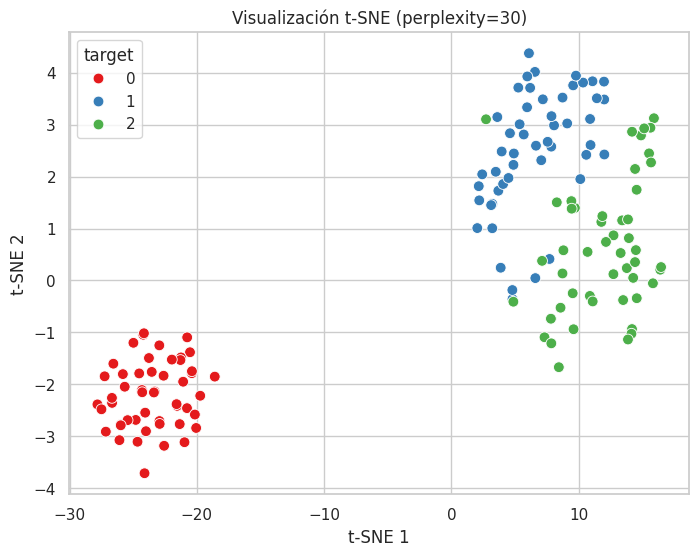


📊 Efecto de la perplexity en t-SNE:


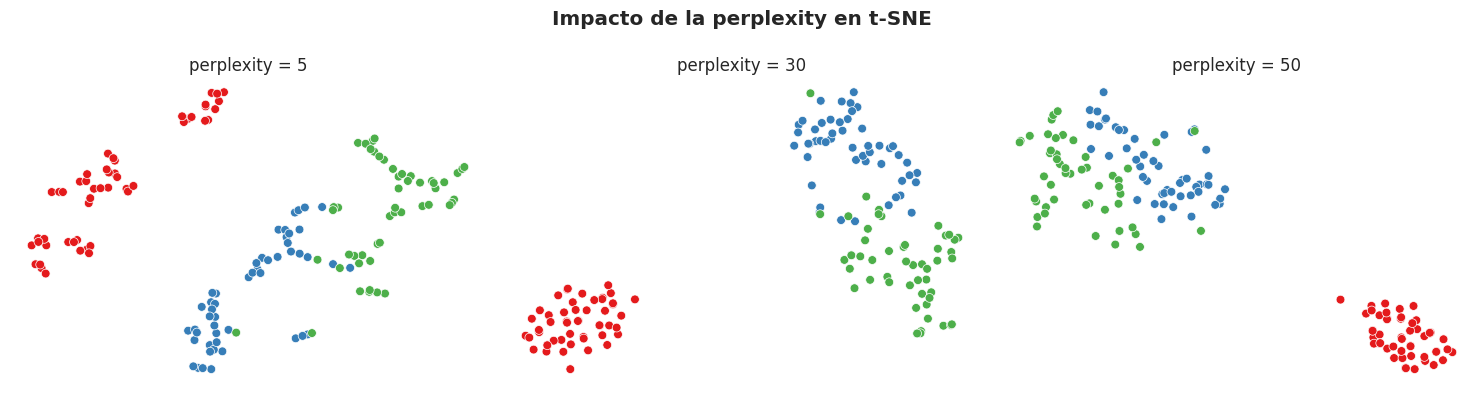

💡 Regla general: perplexity = √(n_muestras). Para Iris (150 muestras) → 12-30 es apropiado.
⚠️  t-SNE es solo para VISUALIZACIÓN — no usar sus coordenadas como features.


In [8]:
print('⏱  Ejecutando t-SNE (puede tardar unos segundos)...')
start = time.time()
tsne = TSNE(n_components=2, random_state=SEED, max_iter=1000, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
t_tsne = time.time() - start
print(f'   t-SNE completado en {t_tsne:.2f}s')

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['target'], palette='Set1', s=60)
plt.title('Visualización t-SNE (perplexity=30)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# Comparar distintas perplexity
print('\n📊 Efecto de la perplexity en t-SNE:')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, perp in zip(axes, [5, 30, 50]):
    t = TSNE(n_components=2, random_state=SEED, max_iter=500, perplexity=perp)
    X_t = t.fit_transform(X_scaled)
    sns.scatterplot(x=X_t[:,0], y=X_t[:,1], hue=df['target'], palette='Set1', s=40, ax=ax, legend=False)
    ax.set_title(f'perplexity = {perp}')
    ax.axis('off')
plt.suptitle('Impacto de la perplexity en t-SNE', fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Regla general: perplexity = √(n_muestras). Para Iris (150 muestras) → 12-30 es apropiado.')
print('⚠️  t-SNE es solo para VISUALIZACIÓN — no usar sus coordenadas como features.')

## 9. Recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Preprocesamiento** | Siempre escalar antes de clustering (StandardScaler o MinMaxScaler) |
| **Elegir K** | Combinar método del codo + silhouette score; no usar solo uno |
| **K-Means** | Usa `n_init=10` (múltiples inicializaciones) para resultados reproducibles |
| **DBSCAN eps** | Calibrar con la distancia al k-ésimo vecino (k = min_samples) |
| **PCA primero** | Aplicar PCA antes de t-SNE en datasets grandes para acelerar el cómputo |
| **t-SNE** | Solo visualización; perplexity ≈ √n, `max_iter` ≥ 1000 para convergencia |
| **Métricas** | Silhouette Score para evaluar cohesión; ARI si tienes etiquetas reales |

> 💡 **Truco:** Para datasets con muchas dimensiones (>50), aplica PCA primero a ~50 dims antes de t-SNE — el resultado visual mejora notablemente y el cómputo es 10× más rápido.

## 10. Discusión y Conclusiones

**¿Qué aprendimos?**

- **K-Means** es el algoritmo de clustering más práctico: rápido y escalable, pero asume clusters esféricos y necesita conocer K de antemano.
- **DBSCAN** encuentra clusters de cualquier forma y detecta outliers automáticamente; su principal reto es calibrar `eps` — la tabla de sensibilidad nos muestra cómo varía con el parámetro.
- **PCA** es la primera herramienta de reducción a considerar: lineal, rápido, y la curva de varianza acumulada indica cuántas componentes son suficientes para preservar el 95% de la información.
- **t-SNE** es poderoso para visualización 2D pero sensible a `perplexity` y no reproducible sin `random_state`; nunca usarlo como features para modelos.
- Combinar PCA + K-Means (o PCA + t-SNE) es una práctica estándar para exploración de datos de alta dimensión.

En el siguiente notebook exploraremos **interpretabilidad de modelos** con SHAP y LIME.

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Aplica K-Means y DBSCAN al dataset `load_digits()`. ¿Cuántos clusters encuentra DBSCAN?

2. **Ejercicio 2:** Varía `eps` de DBSCAN entre 0.3 y 1.0 y grafica el número de clusters vs eps.

3. **Ejercicio 3:** Compara PCA y t-SNE en el dataset Digits. ¿Cuál separa mejor las clases visualmente?

4. **Ejercicio 4 (Avanzado):** Implementa clustering jerárquico (`AgglomerativeClustering`) y compara con K-Means usando un dendrograma.

## 11. Referencias y Recursos

- [Scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [Scikit-learn: Dimensionality Reduction](https://scikit-learn.org/stable/modules/unsupervised_reduction.html)
- [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/)

---

📎 **Notebook anterior:** [09. Autoencoders](./09_autoencoders.ipynb)  
📎 **Notebook siguiente:** [11. Interpretabilidad de Modelos](./11_interpretabilidad_modelos.ipynb)